In [3]:
import pandas as pd
import numpy as np

INPUT_XLSX =  "구급출동(2021.1~2025.5).xlsx"
df = pd.read_excel(INPUT_XLSX, sheet_name=0 ,dtype=str)

In [54]:
df.columns.tolist()

['소방서',
 '119안전센터',
 '차량번호',
 '헬기,펍뷸런스출동유무',
 '년(신고)',
 '월(신고)',
 '요일(신고)',
 '신고시각',
 '접수경로',
 '관할구분',
 '년(출동)',
 '월(출동)',
 '요일(출동)',
 '출동시각',
 '년(현장도착)',
 '월(현장도착)',
 '요일(현장도착)',
 '현장도착시각',
 '현장과의거리(km)',
 '긴급구조시',
 '시군구',
 '지번동',
 '긴급구조리',
 '긴급구조번지',
 '환자분류',
 '출동소방본부',
 '환자접촉시각',
 '접수_min',
 '출동_min',
 '도착_min',
 '출동지연시간',
 '총소요시간',
 '이동시간',
 'flag_이상치후보',
 '요일',
 '접수_시간',
 '시간대',
 '유형',
 '월_num',
 '계절']

In [56]:
def hhmm_to_min(series: pd.Series) -> pd.Series:
    s= series.astype(str).str.strip()
    s=s.replace({'nan':'', 'NaN':'', 'None':'','<NA>':''})
    s=s.where(s.str.match(r'^\d{1,2}:\d{2}$'), np.nan)

    parts =s .str.extract(r'^(\d{1,2}):(\d{2})$')
    hh= parts[0].astype(float)
    mm= parts[1].astype(float)
                        
    out =hh * 60 + mm
    out = out.where((out>=0)&(out <1440), np.nan)
    return out #입력된 HH : MM 형식의 시각 데이터를 분 단위로 변환, 형식이 올바르지 않거나 24시간 범위를 벗어나는 값은 NaN

In [108]:
df.columns

Index(['소방서', '119안전센터', '차량번호', '헬기,펍뷸런스출동유무', '년(신고)', '월(신고)', '요일(신고)',
       '신고시각', '접수경로', '관할구분', '년(출동)', '월(출동)', '요일(출동)', '출동시각', '년(현장도착)',
       '월(현장도착)', '요일(현장도착)', '현장도착시각', '현장과의거리(km)', '긴급구조시', '시군구', '지번동',
       '긴급구조리', '긴급구조번지', '환자분류', '출동소방본부', '환자접촉시각', '접수_min', '출동_min',
       '도착_min', '출동지연시간', '총소요시간', '이동시간', 'flag_이상치후보', '요일', '접수_시간', '시간대',
       '유형', '월_num', '계절'],
      dtype='object')

In [58]:
df["접수_min"] = hhmm_to_min(df["신고시각"])
df["출동_min"] = hhmm_to_min(df["출동시각"])
df["도착_min"] = hhmm_to_min(df["현장도착시각"])

df["출동지연시간"] = df["출동_min"] - df["접수_min"]
df["총소요시간"]   = df["도착_min"] - df["접수_min"]
df["이동시간"] = df["도착_min"] - df["출동_min"]

for c in ["출동지연시간", "총소요시간", "이동시간"]:
    df[c] = np.where(df[c]<0, df[c] + 1440 ,df[c])
    df[["접수_min","출동_min", "도착_min","출동지연시간","총소요시간","이동시간"]].head  #각 시각을 분 단위로 변환한뒤 3가지 시간 계산

In [60]:
print('==== 시각 파싱 결과 NaN 비율 ====')
print(df[['접수_min','출동_min','도착_min']].isna().mean())

print('==== 시간지표 NaN 비율 ====')
print(df[['출동지연시간','총소요시간','이동시간']].isna().mean()) #결측치 비율 확인 , 이후 3가지 시간의 결측비율점검


==== 시각 파싱 결과 NaN 비율 ====
접수_min    0.000000
출동_min    0.000173
도착_min    0.088677
dtype: float64
==== 시간지표 NaN 비율 ====
출동지연시간    0.000173
총소요시간     0.088677
이동시간      0.088680
dtype: float64


In [62]:

def is_abnormal(s:pd.Series) -> pd.Series: 
    return (s<0) | (s>600)

df['flag_이상치후보'] = (
    is_abnormal(df['출동지연시간']) |
    is_abnormal(df['총소요시간']) |
    is_abnormal(df['이동시간']) 
).astype(int)

print('\n=====이상치 후보 개수 ======')
print(df['flag_이상치후보'].value_counts(dropna=False))

print('\n====== 시간 지표 분포 요약 =======')
print(df[['출동지연시간','총소요시간','이동시간']].describe(percentiles = [0.5, 0.7, 0.9, 0.95]))

print('\n========= 문제행 샘플 ===========')
problem_rows = df[
    df[['접수_min','출동_min', '도착_min']].isna().any(axis=1) |
    (df['flag_이상치후보'] == 1)
]

display(problem_rows[['신고시각','출동시각','현장도착시각','접수_min','출동_min','도착_min','출동지연시간', '총소요시간', '이동시간', 'flag_이상치후보']].head(10))
#지연시간  계산이 제대로 되었는지 검증하는 데이터 품질 체크 단계 


=====이상치 후보 개수 ======
flag_이상치후보
0    634452
1       199
Name: count, dtype: int64

====== 시간 지표 분포 요약 =======
              출동지연시간          총소요시간           이동시간
count  634541.000000  578372.000000  578370.000000
mean        4.037377       9.952563       6.191307
std        18.920487      15.541020      17.183823
min         0.000000       0.000000       0.000000
50%         3.000000       8.000000       5.000000
70%         3.000000      10.000000       7.000000
90%         5.000000      14.000000      10.000000
95%         7.000000      20.000000      14.000000
max      1439.000000    1438.000000    1439.000000

========= 문제행 샘플 ===========


,신고시각,출동시각,현장도착시각,접수_min,출동_min,도착_min,출동지연시간,총소요시간,이동시간,flag_이상치후보
2978,09:18,09:20,NaN,558.0,560.0,NaN,2.0,NaN,NaN,0
2979,08:59,14:42,NaN,539.0,882.0,NaN,343.0,NaN,NaN,0
2981,08:51,08:53,NaN,531.0,533.0,NaN,2.0,NaN,NaN,0
2987,17:35,17:39,NaN,1055.0,1059.0,NaN,4.0,NaN,NaN,0
2988,21:23,21:26,NaN,1283.0,1286.0,NaN,3.0,NaN,NaN,0
2993,00:47,00:50,NaN,47.0,50.0,NaN,3.0,NaN,NaN,0
2995,17:30,17:31,NaN,1050.0,1051.0,NaN,1.0,NaN,NaN,0
2998,18:08,18:13,NaN,1088.0,1093.0,NaN,5.0,NaN,NaN,0
2999,21:49,21:51,NaN,1309.0,1311.0,NaN,2.0,NaN,NaN,0
3002,05:12,05:17,NaN,312.0,317.0,NaN,5.0,NaN,NaN,0


In [64]:
df["요일"] = (
    df["요일(신고)"]
    .astype(str)
    .str.strip()
    .str.replace("요일", "" , regex = False)
)

display(df[["요일(신고)", "요일"]].head())
print(df["요일"].value_counts())


,요일(신고),요일
0,금요일,금
1,금요일,금
2,금요일,금
3,토요일,토
4,토요일,토


요일
월    96167
토    92184
금    91951
일    89498
화    88803
목    88617
수    87431
Name: count, dtype: int64


In [66]:
df["접수_시간"] = (df["접수_min"] //60).astype("Int64")

def time_band(hour):
    if pd.isna(hour):
        return np.nan
    h = int(hour)
    if 0 <= h <= 6:
        return "심야" 
    elif 7 <= h <= 9:
        return "출근"
    elif 10 <= h <= 16:
        return "주간"
    elif 17 <= h <= 19:
        return "퇴근"
    elif 20 <= h <= 23:
        return "야간"
    else:
        return np.nan

df["시간대"] = df["접수_시간"].apply(time_band)

display(df[["접수_시간", "시간대"]].head())
print(df["시간대"].value_counts())
        
        
    

,접수_시간,시간대
0,10,주간
1,13,주간
2,15,주간
3,9,출근
4,16,주간


시간대
주간    226804
야간    111479
심야    111033
퇴근     95905
출근     89430
Name: count, dtype: int64


In [23]:
if "월(신고)" in df.columns:
    df["월_num"] = pd.to_numeric(df["월(신고)"], errors="coerce")

    def month_to_season(m):
        if pd.isna(m):
            return np.nan
        m = int(m)
        if m in [12,1,2]:
            return "겨울"
        elif m in [3,4,5]:
            return "봄"
        elif m in [6,7,8]:
            return "여름"
        elif m in [9,10,11]:
            return "가을"
        else:
            return np.nan

    df["계절"] = df["월_num"].apply(month_to_season)

    display(df[["월(신고)","월_num","계절"]].sample(10))
    print(df["계절"].value_counts())

else:
  print("월(신고) 컬럼이 없음")



,월(신고),월_num,계절
165314,3,3,봄
531816,7,7,여름
509681,8,8,여름
315179,9,9,가을
122909,11,11,가을
516404,7,7,여름
483405,6,6,여름
496129,4,4,봄
348731,2,2,겨울
131284,12,12,겨울


계절
봄     172627
겨울    158441
여름    155898
가을    147685
Name: count, dtype: int64


In [70]:
df["유형"]="구급"
display(df[["유형"]].drop_duplicates())

,유형
0,구급


In [44]:
df.rename(columns={
    "긴급구조구" : "시군구",
    "긴급구조동" : "지번동",
    "출동소방서" : "소방서",
    "출동안전센터_지역대" : "119안전센터"
}, inplace=True)

print("컬럼 표준화 완료")
print(sorted(df.columns.tolist()))

컬럼 표준화 완료
['119안전센터', 'flag_이상치후보', '계절', '관할구분', '긴급구조리', '긴급구조번지', '긴급구조시', '년(신고)', '년(출동)', '년(현장도착)', '도착_min', '소방서', '시간대', '시군구', '신고시각', '요일', '요일(신고)', '요일(출동)', '요일(현장도착)', '월(신고)', '월(출동)', '월(현장도착)', '월_num', '유형', '이동시간', '접수_min', '접수_시간', '접수경로', '지번동', '차량번호', '총소요시간', '출동_min', '출동소방본부', '출동시각', '출동지연시간', '헬기,펍뷸런스출동유무', '현장과의거리(km)', '현장도착시각', '환자분류', '환자접촉시각']


In [46]:
required_cols = [
    "접수_min", "출동_min", "도착_min", "출동지연시간", "총소요시간", "이동시간",
    "요일", "시간대", "접수_시간", "계절", "시군구", "지번동","소방서","119안전센터",
    "소방서거리_km","유형"
]

missing = [c for c in required_cols if c not in df.columns]

print("==마스터 컬럼 존재 여부 체크 ==")
if missing:
    print("누락컬럼:", missing)

else:
    print("모든 필수 컬럼 존재")


==마스터 컬럼 존재 여부 체크 ==
누락컬럼: ['소방서거리_km']


In [48]:
MASTER_CSV = "AMBULANCE.csv"

df.to_csv(
    MASTER_CSV,
    index=False,
    encoding="cp949"

)

print(f"분석용 마스터 CSV 저장 완료: {MASTER_CSV}")

분석용 마스터 CSV 저장 완료: AMBULANCE.csv


C:\Users\빅데이터활용센터\AppData\Local\Temp\ipykernel_8644\755848672.py:6: DtypeWarning: Columns (2,3,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AMBULANCE.csv", encoding ="cp949")


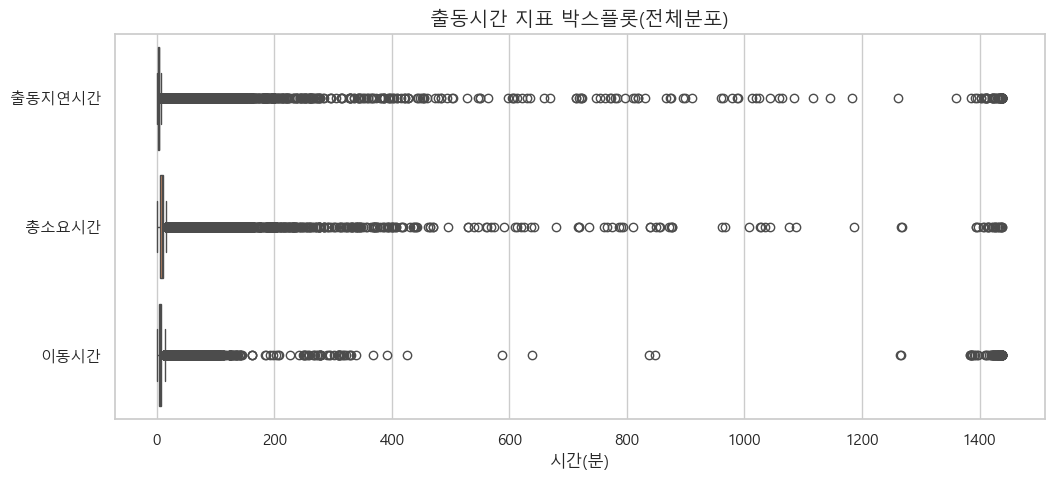

In [52]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd

df = pd.read_csv("AMBULANCE.csv", encoding ="cp949")

sns.set(style="whitegrid")

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,5))

data = df[["출동지연시간", "총소요시간", "이동시간"]]
sns.boxplot(data, orient = "h")

plt.title("출동시간 지표 박스플롯(전체분포)", fontsize=14)
plt.xlabel("시간(분)")
plt.show()
#3가지 시간의 분포를 박스플롯으로 시각화

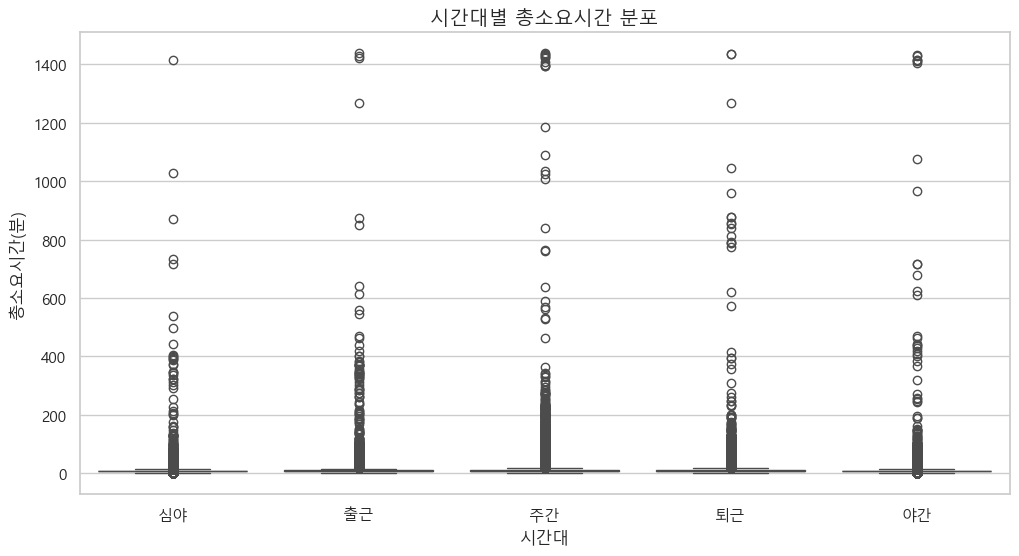

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

sns.set(style="whitegrid")
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="시간대",
    y="총소요시간",
    order=["심야","출근","주간","퇴근","야간"]

)
plt.title("시간대별 총소요시간 분포", fontsize=14)
plt.xlabel("시간대")
plt.ylabel("총소요시간(분)")
plt.show()
#시간대별 총 소요시간 분포를 박스플롯으로 비교하는 시각화 코드

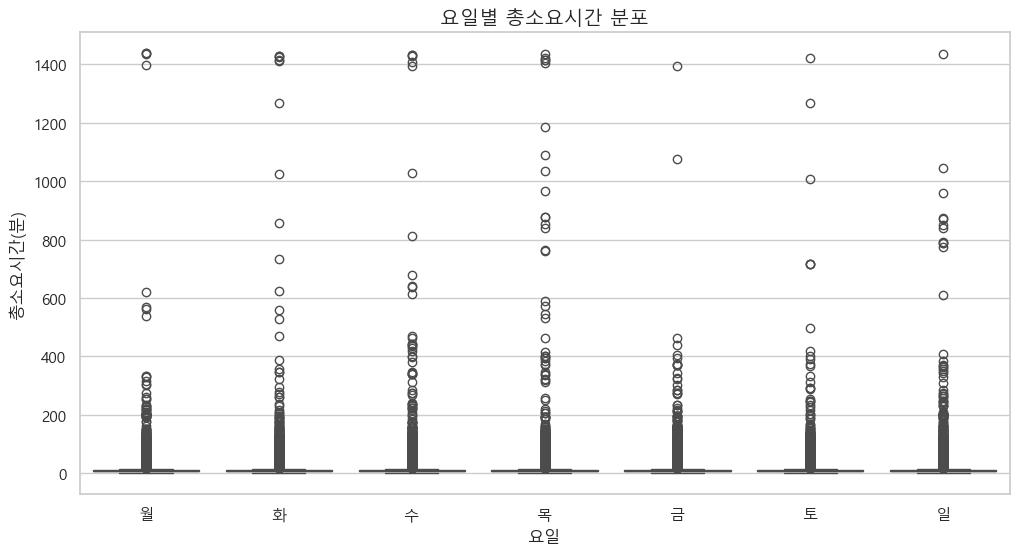

In [82]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="요일",
    y="총소요시간",
    order=["월","화","수","목","금","토","일"]
)

plt.title("요일별 총소요시간 분포", fontsize=14)
plt.xlabel("요일")
plt.ylabel("총소요시간(분)")
plt.show()

In [86]:
summary = (
    df[["출동지연시간", "총소요시간", "이동시간"]]
    .describe(percentiles=[0.5, 0.75 , 0.9 , 0.95])
    .T
)
summary["IQR"] =summary["75%"] - summary["50%"]

summary
#분포 특성 파악하는 코드 
                        

,count,mean,std,min,50%,75%,90%,95%,max,IQR
출동지연시간,634541.0,4.037377,18.920487,0.0,3.0,4.0,5.0,7.0,1439.0,1.0
총소요시간,578372.0,9.952563,15.541020,0.0,8.0,10.0,14.0,20.0,1438.0,2.0
이동시간,578370.0,6.191307,17.183823,0.0,5.0,7.0,10.0,14.0,1439.0,2.0


<function matplotlib.pyplot.show(close=None, block=None)>

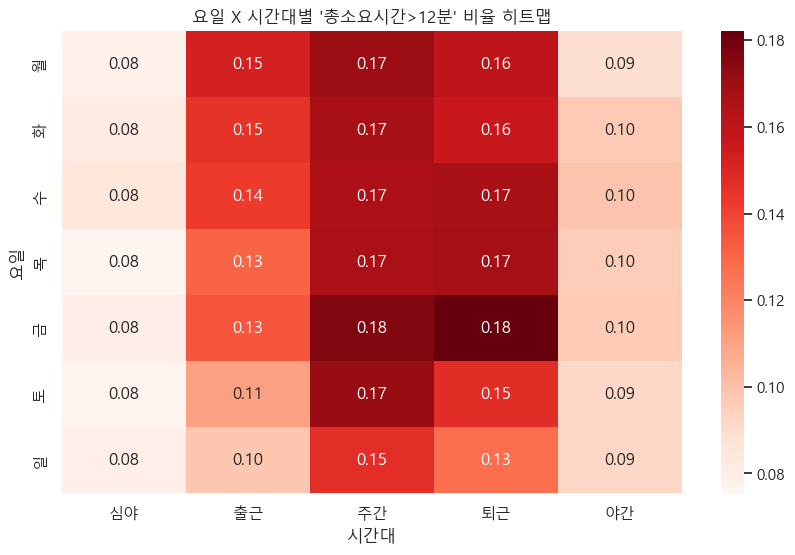

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

TH=12
tmp = df.copy()
tmp["느림"] = (tmp["총소요시간"] > TH).astype(int)

pivot_slow = (
    tmp.groupby(["요일", "시간대"])["느림"]
    .mean()
    .reset_index()
    .pivot(index="요일", columns="시간대", values = "느림")
    .reindex(index= ["월","화","수","목","금","토","일"],
             columns=["심야","출근","주간","퇴근","야간"])
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_slow, annot=True, fmt=".2f", cmap ="Reds")

plt.title(f"요일 X 시간대별 '총소요시간>{TH}분' 비율 히트맵")
plt.xlabel("시간대"); plt.ylabel("요일")
plt.show
# 총소요시간이 12분을 초과하는 경우를 느림으로 정의, 요일과 시간대별 느림 발생 비율을 계산하는  코드 
#피벗 테이블로 재구성한 뒤 히트맵으로 시각화하여 어느 요일 시간대에서 지연이 많이 발생하는지 한눈에 확인

<function matplotlib.pyplot.show(close=None, block=None)>

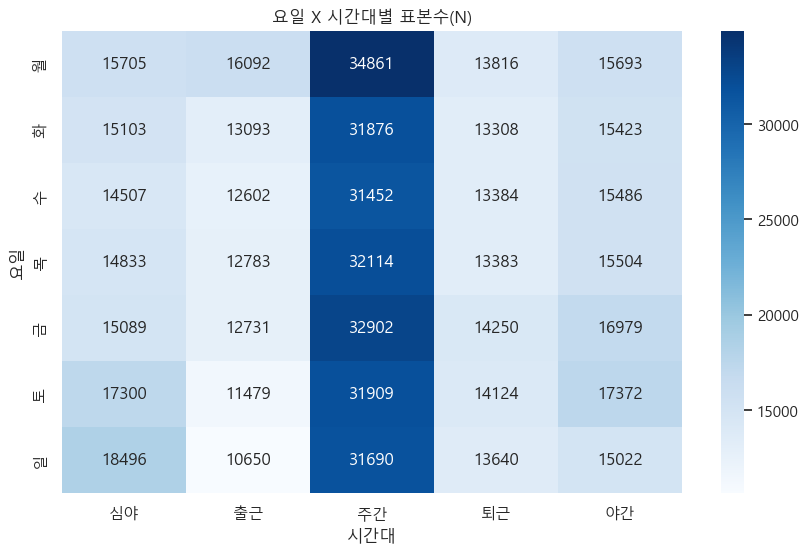

In [100]:
pivot_n = (
    df.groupby(["요일","시간대"])["총소요시간"]
    .size()
    .reset_index(name="N")
    .pivot(index="요일", columns="시간대", values="N")
    .reindex(index= ["월","화","수","목","금","토","일"],
             columns=["심야","출근","주간","퇴근","야간"])
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_n, annot=True, fmt=".0f", cmap ="Blues")

plt.title(f"요일 X 시간대별 표본수(N)")
plt.xlabel("시간대"); plt.ylabel("요일")
plt.show

In [106]:
TH = 12
tmp = df.copy()
tmp["느림"] = (tmp["총소요시간"] > TH).astype(int)

rate_table = (
    tmp.groupby(["요일","시간대"])
    .agg(N=("느림","size"), 느림비율=("느림","mean"))
    .reset_index()

)

rate_table.sort_values("느림비율", ascending= False).head(10)

,요일,시간대,N,느림비율
4,금,퇴근,14250,0.182105
2,금,주간,32902,0.176494
27,토,주간,31909,0.171613
17,월,주간,34861,0.170161
9,목,퇴근,13383,0.168124
32,화,주간,31876,0.167148
14,수,퇴근,13384,0.167140
7,목,주간,32114,0.167092
12,수,주간,31452,0.165522
19,월,퇴근,13816,0.160177


In [ ]:
d